In [1]:
from sklearn.datasets import make_regression
import numpy as np


In [2]:
X,y=make_regression(n_samples=4,n_features=1,n_informative=1,n_targets=1,noise=80,random_state=13)

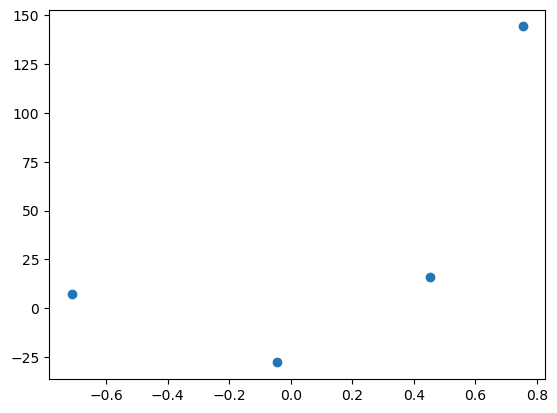

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [4]:
# First Applying OLS
from sklearn.linear_model import LinearRegression

In [5]:
reg=LinearRegression()
reg.fit(X,y)
LinearRegression(copy_X=True,fit_intercept=True,n_jobs=None)

reg.coef_


array([78.35063668])

In [6]:
reg.intercept_ #this we will experimentally check by making the best fit line move and come closer to this answer

np.float64(26.15963284313262)

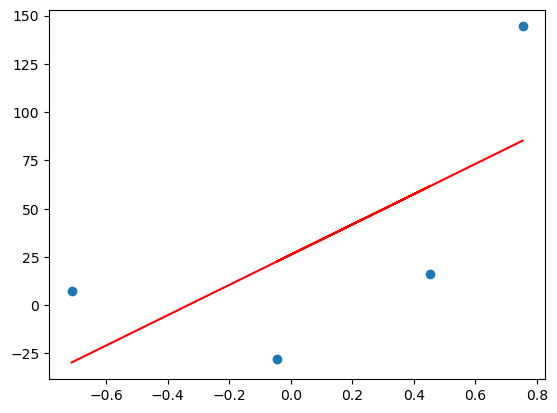

In [7]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')


# Lets Apply Gradient Descent
- Assuming Slope is constant i.e. m=78.35
- Let's Assume the starting value for the intercept b=0 this is like Random Value

In [8]:
y_pred=((78.35*X)+0).reshape(4)

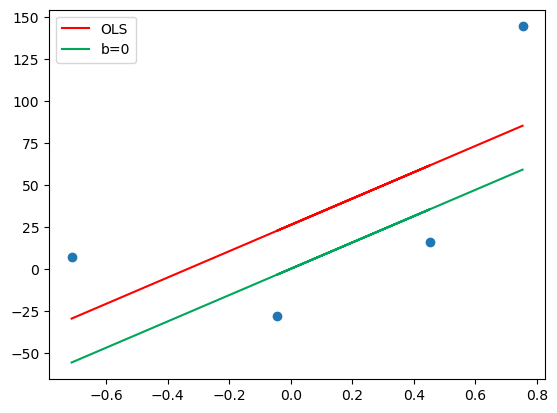

In [9]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b=0')
plt.legend()
plt.show()

# Iteration:1


In [10]:
m=78.35
b=0

loss_slope=-2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-209.27763408209216)

In [11]:
# Lets Learning Rate =0.1
lr=0.1
step_size=loss_slope*lr
step_size

np.float64(-20.927763408209216)

In [12]:
#Calculating new Intercept b_new=b-step_size
b=b-step_size
b

np.float64(20.927763408209216)

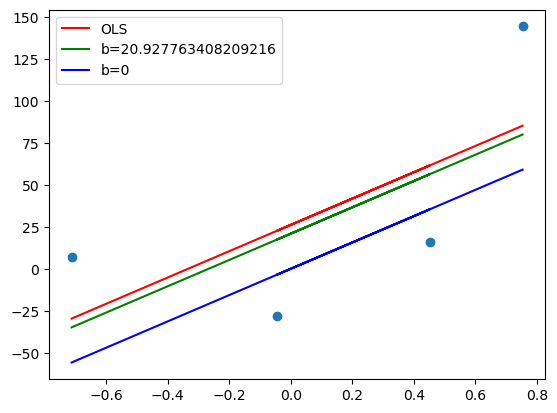

In [13]:
y_pred1=((78.35*X)+b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='green',label='b={}'.format(b))
plt.plot(X,y_pred,color='blue',label='b=0')
plt.legend()
plt.show()

In [14]:
b

np.float64(20.927763408209216)

# Iteration:2

In [15]:

loss_slope=-2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-41.85552681641843)

In [16]:
step_size=loss_slope*lr
step_size

np.float64(-4.185552681641844)

In [17]:
b=b-step_size
b

np.float64(25.11331608985106)

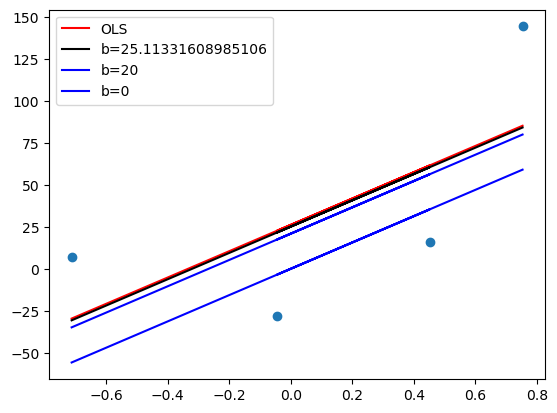

In [18]:
y_pred2=((78.35*X)+b).reshape(4)
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='black',label='b={}'.format(b))
plt.plot(X,y_pred1,color='blue',label='b=20')
plt.plot(X,y_pred,color='blue',label='b=0')

plt.legend()
plt.show()

# Looping for Iterations

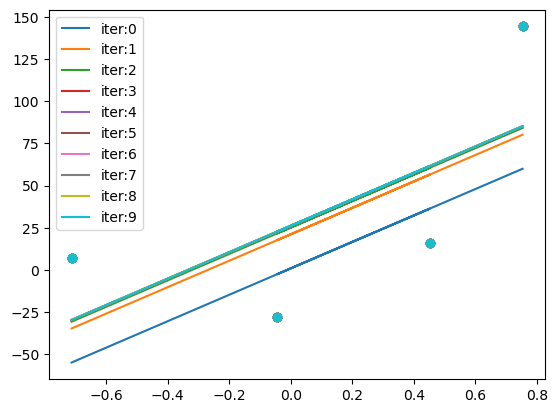

In [19]:
b=-100
m=78.35
lr=0.1

epochs=10 # No. of times loop will run

for i in range(epochs):
    loss_slope=-2*np.sum(y-m*X.ravel()-b)
    step_size=loss_slope*lr
    b=b-step_size

    y_pred3=(m*X)+b

    plt.plot(X,y_pred3,label='iter:{}'.format(i))
    plt.legend()
    plt.scatter(X,y)
